In [22]:
import pandas as pd
df = pd.read_csv("train.csv")

df.head(5)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [24]:
df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [25]:
df.isnull().sum()

,0
PassengerId,0
HomePlanet,201
CryoSleep,217
Cabin,199
Destination,182
Age,179
VIP,203
RoomService,181
FoodCourt,183
ShoppingMall,208


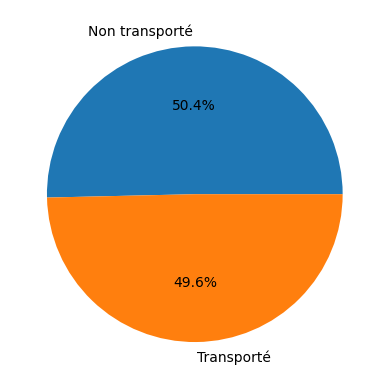

In [26]:
import matplotlib.pyplot as plt

counts = df["Transported"].value_counts()
plt.pie(counts, labels=['Non transporté', 'Transporté'], autopct='%1.1f%%')
plt.show()

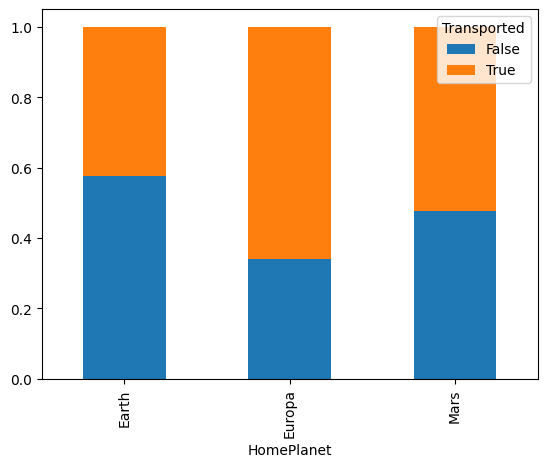

In [27]:
pd.crosstab(df['HomePlanet'], df['Transported'], normalize='index').plot(
    kind='bar', stacked= True
)
plt.show()

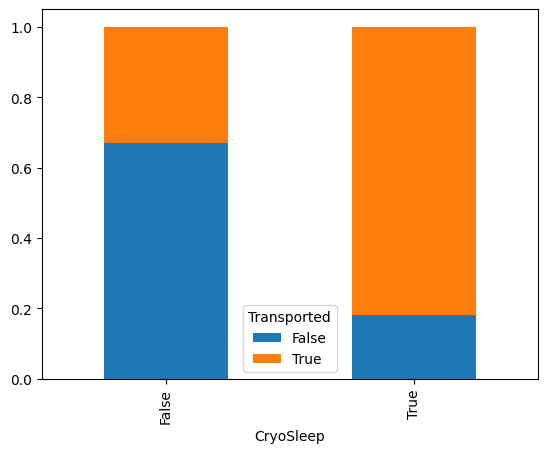

In [28]:
pd.crosstab(df['CryoSleep'], df['Transported'], normalize='index').plot(
    kind='bar', stacked= True
)
plt.show()

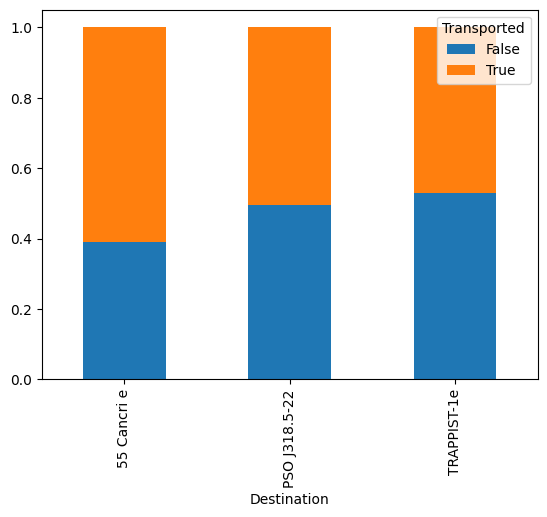

In [29]:
pd.crosstab(df['Destination'], df['Transported'], normalize='index').plot(
    kind='bar', stacked= True
)
plt.show()

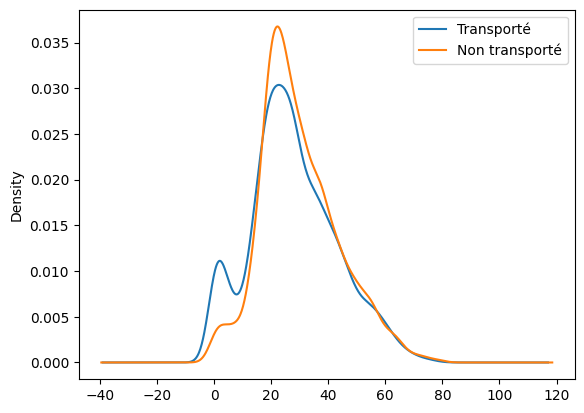

In [30]:
df[df['Transported'] == True]['Age'].dropna().plot(kind='kde', label='Transporté')
df[df['Transported'] == False]['Age'].dropna().plot(kind='kde', label='Non transporté')
plt.legend()
plt.show()

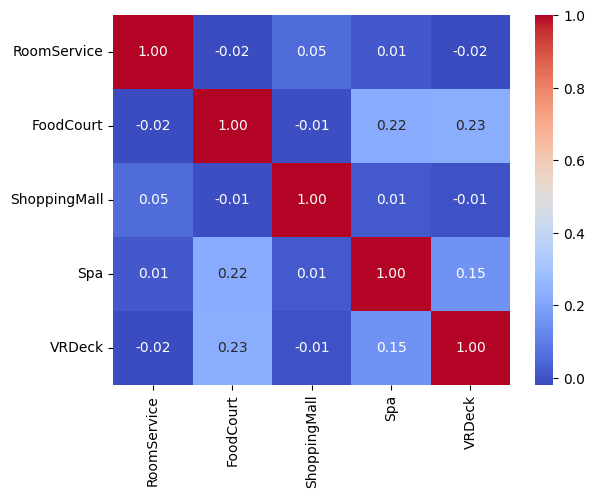

In [31]:
import seaborn as sns

spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

sns.heatmap(df[spending_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()


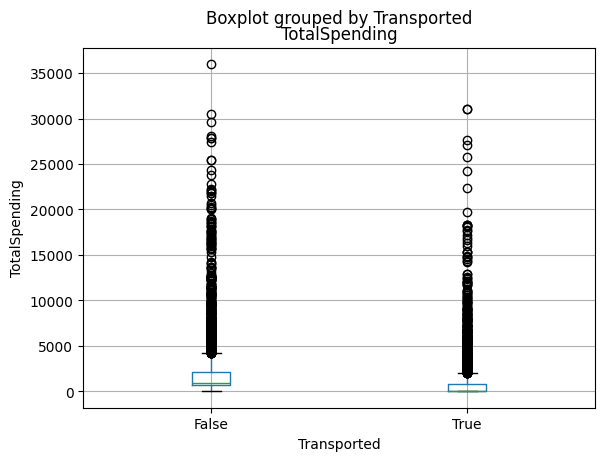

In [32]:
df['TotalSpending'] = df[spending_cols].sum(axis=1)


df.boxplot(column='TotalSpending', by='Transported')
plt.ylabel('TotalSpending')
plt.show()

In [33]:
df[['Deck', 'Num', 'Side']] = df['Cabin'].str.split('/', expand=True)
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,TotalSpending,Deck,Num,Side
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,0.0,B,0,P
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,736.0,F,0,S
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,10383.0,A,0,S
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,5176.0,A,0,S
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,1091.0,F,1,S


In [34]:
df['Group_Id'] = df['PassengerId'].str.split('_').str[0]

In [35]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,TotalSpending,Deck,Num,Side,Group_Id
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,0.0,B,0,P,0001
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,736.0,F,0,S,0002
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,10383.0,A,0,S,0003
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,5176.0,A,0,S,0003
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,1091.0,F,1,S,0004


In [36]:
df['TotalSpending'] = df[spending_cols].sum(axis=1)
df['IsChild'] = (df['Age'] < 13).astype(int)
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,TotalSpending,Deck,Num,Side,Group_Id,IsChild
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,0.0,B,0,P,0001,0
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,736.0,F,0,S,0002,0
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,10383.0,A,0,S,0003,0
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,5176.0,A,0,S,0003,0
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,1091.0,F,1,S,0004,0


In [37]:
for col in spending_cols:
    df.loc[df['CryoSleep'] == True, col] = 0
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,TotalSpending,Deck,Num,Side,Group_Id,IsChild
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,0.0,B,0,P,0001,0
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,736.0,F,0,S,0002,0
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,10383.0,A,0,S,0003,0
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,5176.0,A,0,S,0003,0
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,1091.0,F,1,S,0004,0


In [38]:
df[df['CryoSleep'] == True][spending_cols].sum()

,0
RoomService,0.0
FoodCourt,0.0
ShoppingMall,0.0
Spa,0.0
VRDeck,0.0


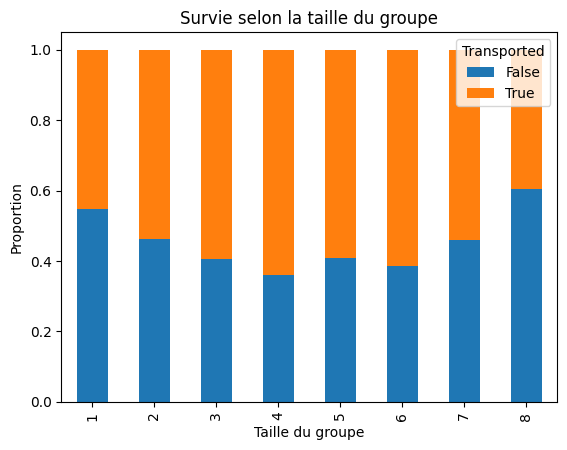

In [39]:
# Taille de chaque groupe
df['Group_Size'] = df.groupby('Group_Id')['Group_Id'].transform('count')

# Comparer survie entre petits et grands groupes
pd.crosstab(df['Group_Size'], df['Transported'], normalize='index').plot(
    kind='bar', stacked=True
)
plt.xlabel('Taille du groupe')
plt.ylabel('Proportion')
plt.title('Survie selon la taille du groupe')
plt.show()


In [40]:
df.groupby('Group_Size')['Transported'].mean().sort_values(ascending=False)

,Transported
Group_Size,
4,0.640777
6,0.614943
3,0.593137
5,0.592453
7,0.541126
2,0.538050
1,0.452445
8,0.394231


In [41]:
df['HomePlanet'] = df.groupby('Group_Id')['HomePlanet'].transform(
    lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else x
)

In [42]:
df[['PassengerId', 'Group_Id', 'HomePlanet']].head(20)

,PassengerId,Group_Id,HomePlanet
0,0001_01,0001,Europa
1,0002_01,0002,Earth
2,0003_01,0003,Europa
3,0003_02,0003,Europa
4,0004_01,0004,Earth
5,0005_01,0005,Earth
6,0006_01,0006,Earth
7,0006_02,0006,Earth
8,0007_01,0007,Earth
9,0008_01,0008,Europa


In [43]:
num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Num', 'TotalSpending']
cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']

# Ensure numeric columns are truly numeric before imputation
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())  # médiane pour les nombres

for col in cat_cols:
    # Convert to category dtype explicitly to handle future warnings and ensure proper categorical treatment
    df[col] = df[col].astype('category').fillna(df[col].mode()[0])  # valeur la plus fréquente pour les catégories


In [44]:
df.isnull().sum()

,0
PassengerId,0
HomePlanet,0
CryoSleep,0
Cabin,199
Destination,0
Age,0
VIP,0
RoomService,0
FoodCourt,0
ShoppingMall,0


In [45]:
features = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
            'TotalSpending', 'IsChild', 'Num',
            'HomePlanet', 'Side', 'CryoSleep', 'Destination', 'VIP', 'Deck']

X = df[features].copy()
y = df['Transported'].astype(int)
print(X.shape)
print(y.shape)

(8693, 15)
(8693,)


In [46]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("train.csv")

# séparer les variables et la cible
X = df.drop("Transported", axis=1)

# garder seulement les variables numériques
X_numeric = X.select_dtypes(include=["int64","float64"])

# appliquer le scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

# remettre dans un dataframe
X_scaled = pd.DataFrame(X_scaled, columns=X_numeric.columns)

In [47]:
df[X_numeric.columns] = scaler.fit_transform(X_numeric)

In [48]:
X_scaled.head()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
0,0.702095,-0.337025,-0.284274,-0.287317,-0.273736,-0.266098
1,-0.333233,-0.173528,-0.278689,-0.245971,0.209267,-0.227692
2,2.013510,-0.272527,1.934922,-0.287317,5.634034,-0.223327
3,0.287964,-0.337025,0.511931,0.326250,2.655075,-0.097634
4,-0.885407,0.117466,-0.240833,-0.037590,0.223344,-0.264352


In [49]:
print(X_scaled)

           Age  RoomService  FoodCourt  ShoppingMall       Spa    VRDeck
0     0.702095    -0.337025  -0.284274     -0.287317 -0.273736 -0.266098
1    -0.333233    -0.173528  -0.278689     -0.245971  0.209267 -0.227692
2     2.013510    -0.272527   1.934922     -0.287317  5.634034 -0.223327
3     0.287964    -0.337025   0.511931      0.326250  2.655075 -0.097634
4    -0.885407     0.117466  -0.240833     -0.037590  0.223344 -0.264352
...        ...          ...        ...           ...       ...       ...
8688  0.840138    -0.337025   3.947464     -0.287317  1.171754 -0.201506
8689 -0.747364    -0.337025  -0.284274     -0.287317 -0.273736 -0.266098
8690 -0.195189    -0.337025  -0.284274      2.808634 -0.272856 -0.266098
8691  0.218942    -0.337025   0.366715     -0.287317  0.036829  2.557627
8692  1.047204    -0.148029   2.625008     -0.287317 -0.273736 -0.255623

[8693 rows x 6 columns]


In [50]:
X_scaled.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8.514000e+03,8.512000e+03,8.510000e+03,8.485000e+03,8.510000e+03,8505.000000
mean,6.217458e-17,-1.419082e-17,-1.669901e-17,5.443168e-18,2.087376e-17,0.000000
std,1.000059e+00,1.000059e+00,1.000059e+00,1.000059e+00,1.000059e+00,1.000059
min,-1.989756e+00,-3.370254e-01,-2.842738e-01,-2.873167e-01,-2.737359e-01,-0.266098
25%,-6.783417e-01,-3.370254e-01,-2.842738e-01,-2.873167e-01,-2.737359e-01,-0.266098
50%,-1.261671e-01,-3.370254e-01,-2.842738e-01,-2.873167e-01,-2.737359e-01,-0.266098
75%,6.330730e-01,-2.665267e-01,-2.371097e-01,-2.426636e-01,-2.218284e-01,-0.225946
max,3.462968e+00,2.115309e+01,1.821709e+01,3.856422e+01,1.944053e+01,20.798803


In [51]:
X_scaled.shape

(8693, 6)

In [52]:
# HomePlanet : onehot encoding /ordinal encoding pour le deck

df = pd.get_dummies(df, columns=["HomePlanet"])

In [53]:
df["Deck"] = df["Cabin"].str.split("/").str[0]

In [54]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()

df[["Deck"]] = encoder.fit_transform(df[["Deck"]])

In [55]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

# charger les données
df = pd.read_csv("train.csv")

# nettoyer les noms de colonnes (évite les erreurs KeyError)
df.columns = df.columns.str.strip()



df = pd.get_dummies(df, columns=["HomePlanet"])



df["Deck"] = df["Cabin"].str.split("/").str[0]

encoder = OrdinalEncoder()

df[["Deck"]] = encoder.fit_transform(df[["Deck"]])


print(df.head())

  PassengerId CryoSleep  Cabin  Destination   Age    VIP  RoomService  \
0     0001_01     False  B/0/P  TRAPPIST-1e  39.0  False          0.0   
1     0002_01     False  F/0/S  TRAPPIST-1e  24.0  False        109.0   
2     0003_01     False  A/0/S  TRAPPIST-1e  58.0   True         43.0   
3     0003_02     False  A/0/S  TRAPPIST-1e  33.0  False          0.0   
4     0004_01     False  F/1/S  TRAPPIST-1e  16.0  False        303.0   

   FoodCourt  ShoppingMall     Spa  VRDeck               Name  Transported  \
0        0.0           0.0     0.0     0.0    Maham Ofracculy        False   
1        9.0          25.0   549.0    44.0       Juanna Vines         True   
2     3576.0           0.0  6715.0    49.0      Altark Susent        False   
3     1283.0         371.0  3329.0   193.0       Solam Susent        False   
4       70.0         151.0   565.0     2.0  Willy Santantines         True   

   HomePlanet_Earth  HomePlanet_Europa  HomePlanet_Mars  Deck  
0             False         

In [56]:
import pandas as pd
import numpy as np

if "HomePlanet" in df.columns:
    df = pd.get_dummies(df, columns=["HomePlanet"])
else:
    print("HomePlanet déjà transformé ou absent, on skip le get_dummies.")


def cabin_to_deck(cabin):
    if pd.isna(cabin):
        return np.nan
    return ord(cabin.split('/')[0].upper()) - ord('A')  # A->0, B->1, C->2, ...

df['Deck'] = df['Cabin'].apply(cabin_to_deck)


print(df.head())

HomePlanet déjà transformé ou absent, on skip le get_dummies.
  PassengerId CryoSleep  Cabin  Destination   Age    VIP  RoomService  \
0     0001_01     False  B/0/P  TRAPPIST-1e  39.0  False          0.0   
1     0002_01     False  F/0/S  TRAPPIST-1e  24.0  False        109.0   
2     0003_01     False  A/0/S  TRAPPIST-1e  58.0   True         43.0   
3     0003_02     False  A/0/S  TRAPPIST-1e  33.0  False          0.0   
4     0004_01     False  F/1/S  TRAPPIST-1e  16.0  False        303.0   

   FoodCourt  ShoppingMall     Spa  VRDeck               Name  Transported  \
0        0.0           0.0     0.0     0.0    Maham Ofracculy        False   
1        9.0          25.0   549.0    44.0       Juanna Vines         True   
2     3576.0           0.0  6715.0    49.0      Altark Susent        False   
3     1283.0         371.0  3329.0   193.0       Solam Susent        False   
4       70.0         151.0   565.0     2.0  Willy Santantines         True   

   HomePlanet_Earth  HomePlane

In [57]:
# Numéro de cabine
df['CabinNum'] = df['Cabin'].apply(lambda x: int(x.split('/')[1]) if pd.notna(x) else np.nan)

# Side de cabine
df['CabinSide'] = df['Cabin'].apply(lambda x: x.split('/')[2] if pd.notna(x) else np.nan)

# One-hot pour CabinSide
df = pd.get_dummies(df, columns=['CabinSide'])

In [58]:
print(df.isna().sum())

PassengerId            0
CryoSleep            217
Cabin                199
Destination          182
Age                  179
VIP                  203
RoomService          181
FoodCourt            183
ShoppingMall         208
Spa                  183
VRDeck               188
Name                 200
Transported            0
HomePlanet_Earth       0
HomePlanet_Europa      0
HomePlanet_Mars        0
Deck                 199
CabinNum             199
CabinSide_P            0
CabinSide_S            0
dtype: int64


In [59]:
num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CabinNum']
df[num_cols] = df[num_cols].fillna(0)

bool_cols = ['VIP', 'CryoSleep']
df[bool_cols] = df[bool_cols].fillna(False)

/tmp/ipykernel_8206/2764740279.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[bool_cols] = df[bool_cols].fillna(False)


In [60]:
df = pd.get_dummies(df, columns=['Destination'])

In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_features = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CabinNum']
df[num_features] = scaler.fit_transform(df[num_features])

In [62]:
X = df.drop(columns=['Transported', 'PassengerId', 'Name', 'Cabin'])  # features
y = df['Transported']  # cible

In [63]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split

# On split les données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# On crée un modèle de base
rf = RandomForestClassifier(random_state=42)

# Hyperparamètres à tester
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
}

# Grid Search
grid = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print("Meilleurs paramètres :", grid.best_params_)
print("Meilleure accuracy :", grid.best_score_)

Meilleurs paramètres : {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Meilleure accuracy : 0.8050046289352414


In [64]:
best_model = grid.best_estimator_

In [65]:
from sklearn.metrics import accuracy_score

y_pred = best_model.predict(X_test)
print("Accuracy sur le test set :", accuracy_score(y_test, y_pred))

Accuracy sur le test set : 0.7941345600920069


In [66]:
df['TotalSpending'] = df[['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']].sum(axis=1)